   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


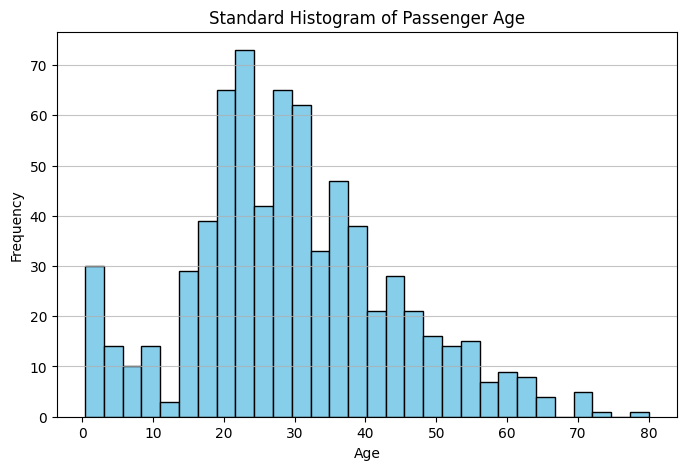

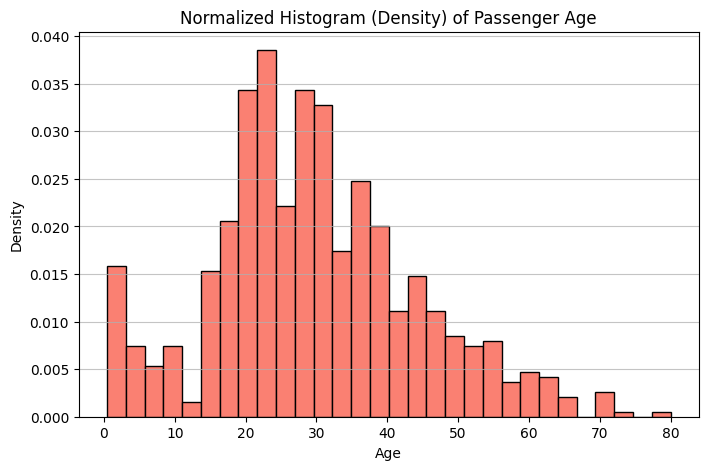

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (Titanic dataset from Kaggle, hosted on GitHub for easy access)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Show first few rows
print(df.head())

# 1. Standard Histogram of Passenger Age
plt.figure(figsize=(8,5))
plt.hist(df['Age'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Standard Histogram of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()
# Description:
# Titanic dataset contains passenger info such as Age, Sex, Class, etc.
# Here we show the raw counts of passengers grouped by age.

# 2. Normalized Histogram (Density) of Passenger Age
plt.figure(figsize=(8,5))
plt.hist(df['Age'].dropna(), bins=30, density=True, color='salmon', edgecolor='black')
plt.title('Normalized Histogram (Density) of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.75)
plt.show()
# Description:
# This normalized histogram shows the probability density, summing area to 1,
# useful to compare relative frequencies r


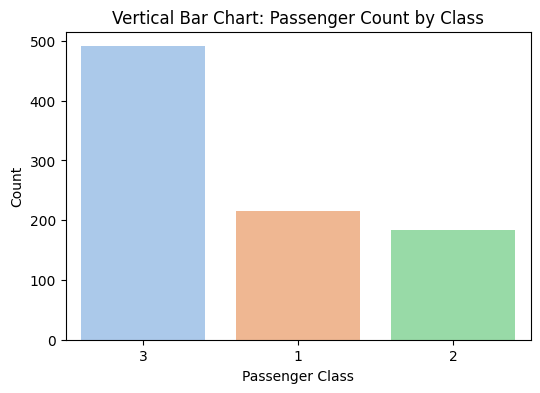

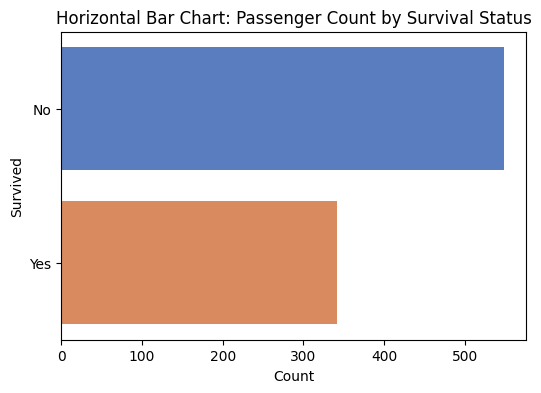

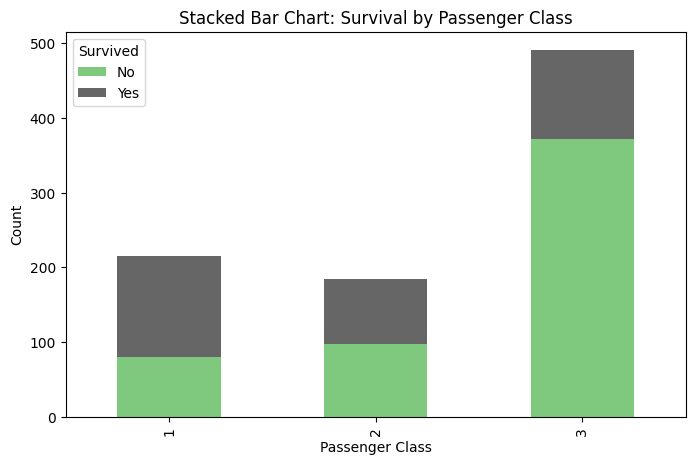

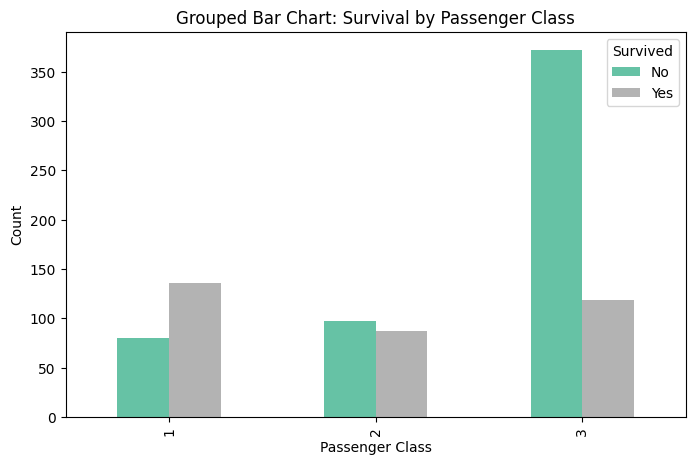

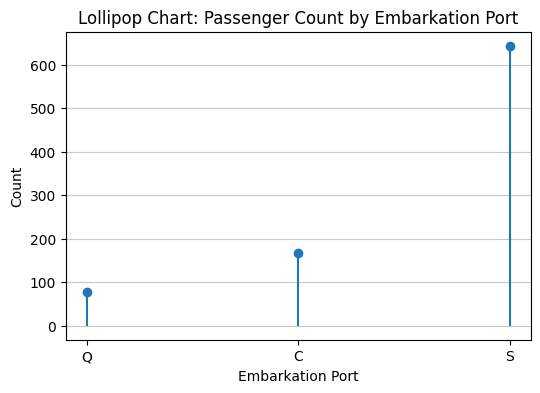

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Prepare categorical variables
df['Survived'] = df['Survived'].map({0: 'No', 1: 'Yes'})
df['Pclass'] = df['Pclass'].astype(str)

# 1. Vertical Bar Chart: Count of passengers by class (fixed FutureWarning)
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Pclass', data=df, palette='pastel', dodge=False, legend=False)
plt.title('Vertical Bar Chart: Passenger Count by Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()

# 2. Horizontal Bar Chart: Count of passengers by survival (fix with hue)
plt.figure(figsize=(6,4))
sns.countplot(y='Survived', hue='Survived', data=df, palette='muted', dodge=False, legend=False)
plt.title('Horizontal Bar Chart: Passenger Count by Survival Status')
plt.ylabel('Survived')
plt.xlabel('Count')
plt.show()

# 3. Stacked Bar Chart: Survival counts within each passenger class
survived_class = pd.crosstab(df['Pclass'], df['Survived'])
survived_class.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Accent')
plt.title('Stacked Bar Chart: Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(title='Survived')
plt.show()

# 4. Grouped Bar Chart: Survival counts by passenger class side-by-side
survived_class.plot(kind='bar', stacked=False, figsize=(8,5), colormap='Set2')
plt.title('Grouped Bar Chart: Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(title='Survived')
plt.show()

# 5. Lollipop Chart: Count of passengers by embarkation port
embark_counts = df['Embarked'].value_counts().sort_values()
plt.figure(figsize=(6,4))
plt.stem(embark_counts.index, embark_counts.values, basefmt=" ")
plt.title('Lollipop Chart: Passenger Count by Embarkation Port')
plt.xlabel('Embarkation Port')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.7)
plt.show()


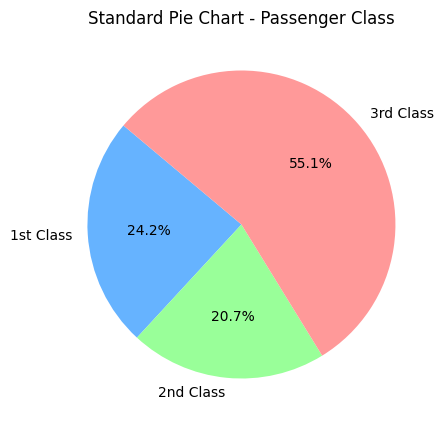

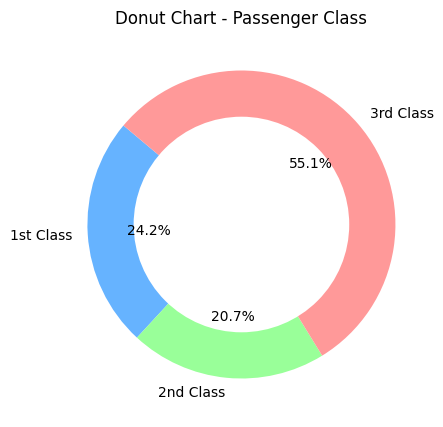

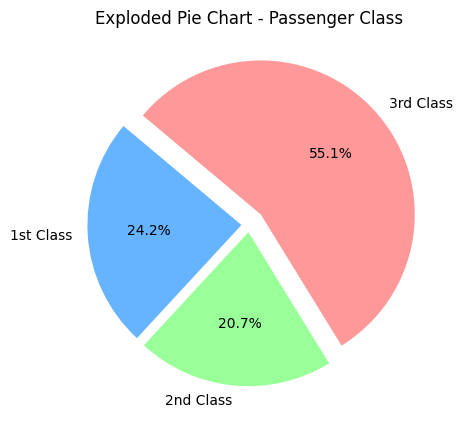

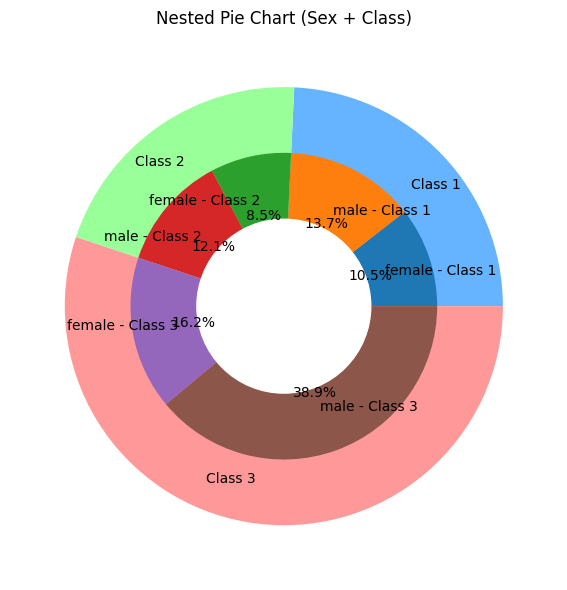

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Category for pie charts: 'Pclass'
pclass_counts = df['Pclass'].value_counts().sort_index()
labels = ['1st Class', '2nd Class', '3rd Class']
colors = ['#66b3ff', '#99ff99', '#ff9999']

# 1. Standard Pie Chart
plt.figure(figsize=(5,5))
plt.pie(pclass_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Standard Pie Chart - Passenger Class')
plt.show()

# 2. Donut Chart
plt.figure(figsize=(5,5))
wedges, texts, autotexts = plt.pie(pclass_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Donut Chart - Passenger Class')
plt.show()

# 3. Exploded Pie Chart
explode = (0.05, 0.05, 0.1)  # "explode" 3rd class a bit more
plt.figure(figsize=(5,5))
plt.pie(pclass_counts, labels=labels, colors=colors, autopct='%1.1f%%', explode=explode, startangle=140)
plt.title('Exploded Pie Chart - Passenger Class')
plt.show()

# 4. Nested Pie Chart (Sunburst-like using Gender + Pclass)
grouped = df.groupby(['Sex', 'Pclass']).size().unstack()
outer_labels = grouped.columns.map(lambda x: f'Class {x}')
outer_counts = grouped.sum()
inner_labels = [f'{sex} - Class {cls}' for cls in grouped.columns for sex in grouped.index]
inner_counts = grouped.T.values.flatten()

# Outer ring
plt.figure(figsize=(6,6))
ax = plt.subplot()
ax.pie(outer_counts, radius=1, labels=outer_labels, labeldistance=0.8, colors=colors)

# Inner ring
ax.pie(inner_counts, radius=0.7, labels=inner_labels, labeldistance=0.7, autopct='%1.1f%%')

centre_circle = plt.Circle((0,0),0.4,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Nested Pie Chart (Sex + Class)")
plt.tight_layout()
plt.show()


Summary Statistics for Age:

Min: 0.42
Q1 : 20.12
Median (Q2): 28.00
Q3 : 38.00
Max: 80.00


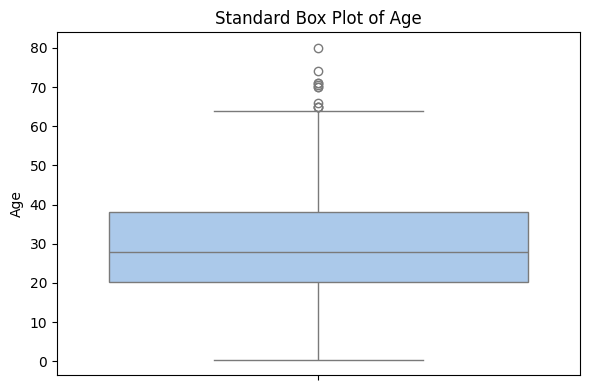

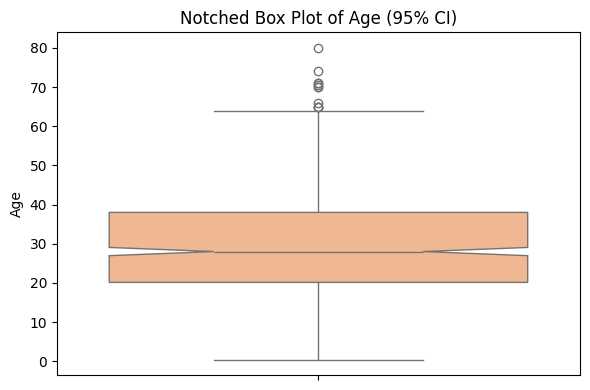

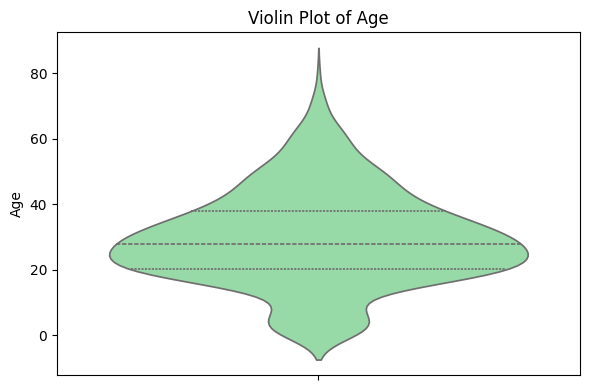

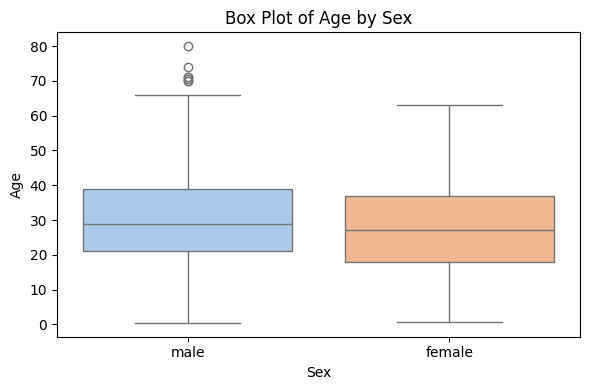

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Drop missing Age values for plotting
df = df.dropna(subset=['Age'])

# Summary Statistics
summary_stats = df['Age'].describe()
print("Summary Statistics for Age:\n")
print(f"Min: {summary_stats['min']:.2f}")
print(f"Q1 : {df['Age'].quantile(0.25):.2f}")
print(f"Median (Q2): {summary_stats['50%']:.2f}")
print(f"Q3 : {df['Age'].quantile(0.75):.2f}")
print(f"Max: {summary_stats['max']:.2f}")

# Color Palette
palette = sns.color_palette("pastel")

# 1. Standard Box Plot
plt.figure(figsize=(6, 4))
sns.boxplot(y='Age', data=df, color=palette[0])
plt.title('Standard Box Plot of Age')
plt.tight_layout()
plt.show()

# 2. Notched Box Plot (with 95% CI)
plt.figure(figsize=(6, 4))
sns.boxplot(y='Age', data=df, notch=True, color=palette[1])
plt.title('Notched Box Plot of Age (95% CI)')
plt.tight_layout()
plt.show()

# 3. Violin Plot
plt.figure(figsize=(6, 4))
sns.violinplot(y='Age', data=df, inner='quartile', color=palette[2])
plt.title('Violin Plot of Age')
plt.tight_layout()
plt.show()

# 4. Side-by-side Box Plot (by Sex) - updated with hue
plt.figure(figsize=(6, 4))
sns.boxplot(x='Sex', y='Age', data=df, hue='Sex', palette='pastel', legend=False)
plt.title("Box Plot of Age by Sex")
plt.tight_layout()
plt.show()
